## ML_04 EDA — VSCode 실행 버전

**실행 순서**: 셀1(환경설정+폰트) → 이후 순서대로 실행  
런타임 재시작 불필요. VSCode에서 바로 실행 가능.


In [1]:
# ── Step 1. 환경설정 + 폰트 + 데이터 로드 ────────────────────
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl

font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
mpl.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
mpl.rcParams['axes.unicode_minus'] = False
print(f"폰트 설정 완료: {font_name}")

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

BASE = r"C:/Users/hoo58/OneDrive/바탕 화면/tables/DATA/eda_ready_new/"

print("데이터 로드 중...")
ad_outcome = pd.read_parquet(BASE + 'ad_outcome.parquet')
finance1   = pd.read_parquet(BASE + 'finance_clean1.parquet')
finance2   = pd.read_parquet(BASE + 'finance_clean2.parquet')
sched      = pd.read_parquet(BASE + 'sched_clean.parquet')
ad_attr    = pd.read_parquet(BASE + 'ad_attr_map.parquet')

finance = pd.concat([finance1, finance2], ignore_index=True)
print(f"ad_outcome : {ad_outcome.shape}")
print(f"finance    : {finance.shape}")
print(f"sched      : {sched.shape}")
print(f"ad_attr    : {ad_attr.shape}")

# 유효 광고
valid = ad_outcome[ad_outcome['is_valid_click10'] == 1].copy()

# finance 광고별 집계
fin_agg = finance.groupby('ads_idx').agg(
    total_adv_cost = ('adv_cost', 'sum'),
    total_margin   = ('ive_margin', 'sum'),
    complete_cnt_f = ('rwd_idx', 'count'),
    avg_ctit       = ('ctit', 'mean'),
).reset_index()
fin_agg['margin_per_complete'] = fin_agg['total_margin'] / fin_agg['complete_cnt_f'].replace(0, np.nan)
fin_agg['margin_rate']         = fin_agg['total_margin'] / fin_agg['total_adv_cost'].replace(0, np.nan)

# 보정 CVR (alpha=10)
global_cvr = valid['complete_cnt'].sum() / valid['click_cnt'].sum()
valid = valid.copy()
valid['smoothed_cvr'] = (
    (valid['complete_cnt'] + 10 * global_cvr) / (valid['click_cnt'] + 10) * 100
)

# 분석용 마스터 테이블
master = (valid[['ads_idx','click_cnt','complete_cnt','cvr_pct','smoothed_cvr',
                  'ads_type_label','analysis_ads_type_label','reward_band']]
          .merge(fin_agg, on='ads_idx', how='left'))

# sched elapsed_day 계산
sched2 = sched.copy()
sched2['click_date_dt'] = pd.to_datetime(sched2['click_date'])
sched2['ads_sdate_dt']  = pd.to_datetime(sched2['ads_sdate'])
sched2['elapsed_day']   = (sched2['click_date_dt'] - sched2['ads_sdate_dt']).dt.days

print(f"\n분석 대상 광고: {len(master):,}건")
print("✅ 환경 설정 및 데이터 로드 완료")


폰트 설정 완료: Malgun Gothic
데이터 로드 중...
ad_outcome : (445260, 22)
finance    : (2858560, 33)
sched      : (473066, 21)
ad_attr    : (445260, 18)

분석 대상 광고: 5,281건
✅ 환경 설정 및 데이터 로드 완료




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EDA 1. 품질 점수 구성 지표 분포
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
전체 광고: 445,260  |  유효 광고(클릭≥10): 5,281  (1.2%)

[CVR 기초 통계]
count    5281.00
mean       60.75
std        26.71
min         0.00
10%        11.63
25%        48.03
50%        70.00
75%        80.00
90%        86.32
95%        90.21
max       100.00
Name: cvr_pct, dtype: float64


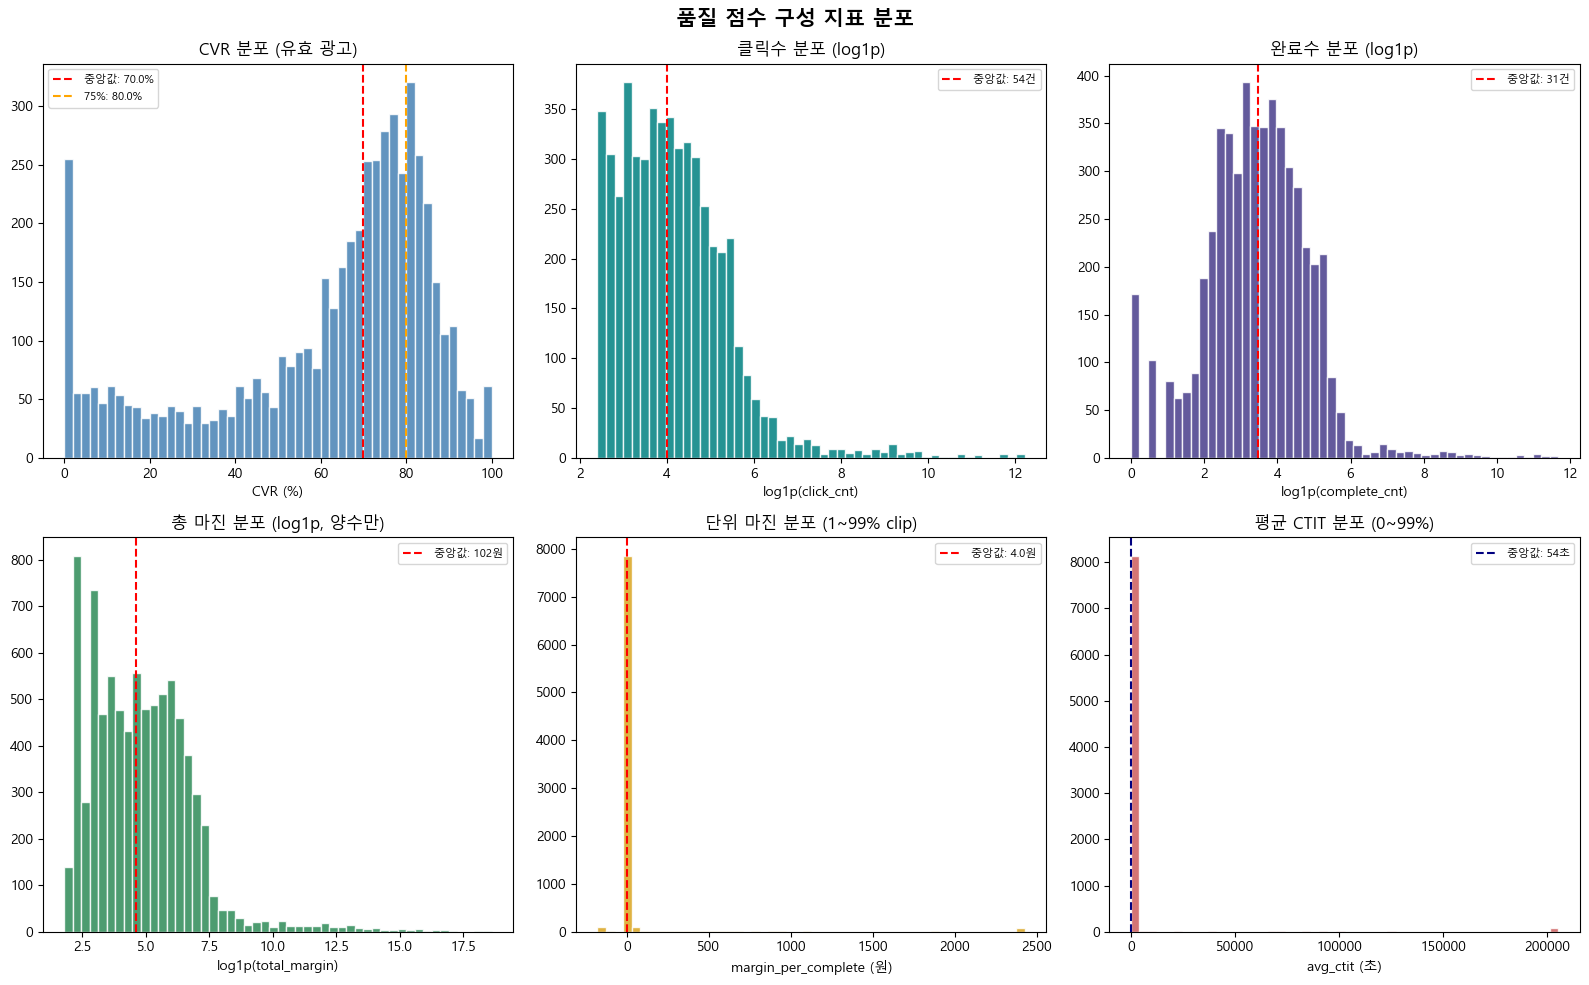

In [2]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("EDA 1. 품질 점수 구성 지표 분포")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

valid = ad_outcome[ad_outcome['is_valid_click10'] == 1].copy()
print(f"전체 광고: {len(ad_outcome):,}  |  유효 광고(클릭≥10): {len(valid):,}  ({len(valid)/len(ad_outcome)*100:.1f}%)")

# finance 집계
fin_agg = finance.groupby('ads_idx').agg(
    total_adv_cost = ('adv_cost', 'sum'),
    total_margin   = ('ive_margin', 'sum'),
    complete_cnt_f = ('rwd_idx', 'count'),
    avg_ctit       = ('ctit', 'mean'),
).reset_index()
fin_agg['margin_per_complete'] = fin_agg['total_margin'] / fin_agg['complete_cnt_f'].replace(0, np.nan)
fin_agg['margin_rate']         = fin_agg['total_margin'] / fin_agg['total_adv_cost'].replace(0, np.nan)

print("\n[CVR 기초 통계]")
print(valid['cvr_pct'].describe(percentiles=[.1,.25,.5,.75,.9,.95]).round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('품질 점수 구성 지표 분포', fontsize=15, fontweight='bold')

# CVR
ax = axes[0, 0]
ax.hist(valid['cvr_pct'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(valid['cvr_pct'].median(), color='red', linestyle='--',
           label=f"중앙값: {valid['cvr_pct'].median():.1f}%")
ax.axvline(valid['cvr_pct'].quantile(0.75), color='orange', linestyle='--',
           label=f"75%: {valid['cvr_pct'].quantile(0.75):.1f}%")
ax.set_title('CVR 분포 (유효 광고)')
ax.set_xlabel('CVR (%)')
ax.legend(fontsize=8)

# 클릭수 (log)
ax = axes[0, 1]
ax.hist(np.log1p(valid['click_cnt']), bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(np.log1p(valid['click_cnt'].median()), color='red', linestyle='--',
           label=f"중앙값: {valid['click_cnt'].median():.0f}건")
ax.set_title('클릭수 분포 (log1p)')
ax.set_xlabel('log1p(click_cnt)')
ax.legend(fontsize=8)

# 완료수 (log)
ax = axes[0, 2]
ax.hist(np.log1p(valid['complete_cnt']), bins=50, color='darkslateblue', edgecolor='white', alpha=0.85)
ax.axvline(np.log1p(valid['complete_cnt'].median()), color='red', linestyle='--',
           label=f"중앙값: {valid['complete_cnt'].median():.0f}건")
ax.set_title('완료수 분포 (log1p)')
ax.set_xlabel('log1p(complete_cnt)')
ax.legend(fontsize=8)

# 총 마진 (log, 양수만)
ax = axes[1, 0]
pos_margin = fin_agg[fin_agg['total_margin'] > 0]['total_margin']
ax.hist(np.log1p(pos_margin), bins=50, color='seagreen', edgecolor='white', alpha=0.85)
ax.axvline(np.log1p(pos_margin.median()), color='red', linestyle='--',
           label=f"중앙값: {pos_margin.median():,.0f}원")
ax.set_title('총 마진 분포 (log1p, 양수만)')
ax.set_xlabel('log1p(total_margin)')
ax.legend(fontsize=8)

# 단위 마진
ax = axes[1, 1]
unit_m = fin_agg['margin_per_complete'].dropna()
unit_m_clip = unit_m.clip(unit_m.quantile(0.01), unit_m.quantile(0.99))
ax.hist(unit_m_clip, bins=50, color='goldenrod', edgecolor='white', alpha=0.85)
ax.axvline(unit_m.median(), color='red', linestyle='--',
           label=f"중앙값: {unit_m.median():.1f}원")
ax.set_title('단위 마진 분포 (1~99% clip)')
ax.set_xlabel('margin_per_complete (원)')
ax.legend(fontsize=8)

# avg_ctit
ax = axes[1, 2]
ctit = fin_agg['avg_ctit'].dropna()
ctit_clip = ctit.clip(0, ctit.quantile(0.99))
ax.hist(ctit_clip, bins=50, color='indianred', edgecolor='white', alpha=0.85)
ax.axvline(ctit.median(), color='navy', linestyle='--',
           label=f"중앙값: {ctit.median():.0f}초")
ax.set_title('평균 CTIT 분포 (0~99%)')
ax.set_xlabel('avg_ctit (초)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EDA 2. 운영 안정성 지표
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[운영 일수]
count    445260.0
mean          0.1
std           0.9
min           0.0
25%           0.0
50%           0.0
75%           0.0
90%           0.0
95%           0.0
99%           3.0
max          31.0
Name: total_days, dtype: float64

[일별 CVR 변동성(std)]
count    6267.00
mean       21.19
std        18.42
min         0.00
25%         5.66
50%        17.68
75%        33.20
90%        50.00
95%        57.74
max        70.71
Name: daily_cvr_std, dtype: float64


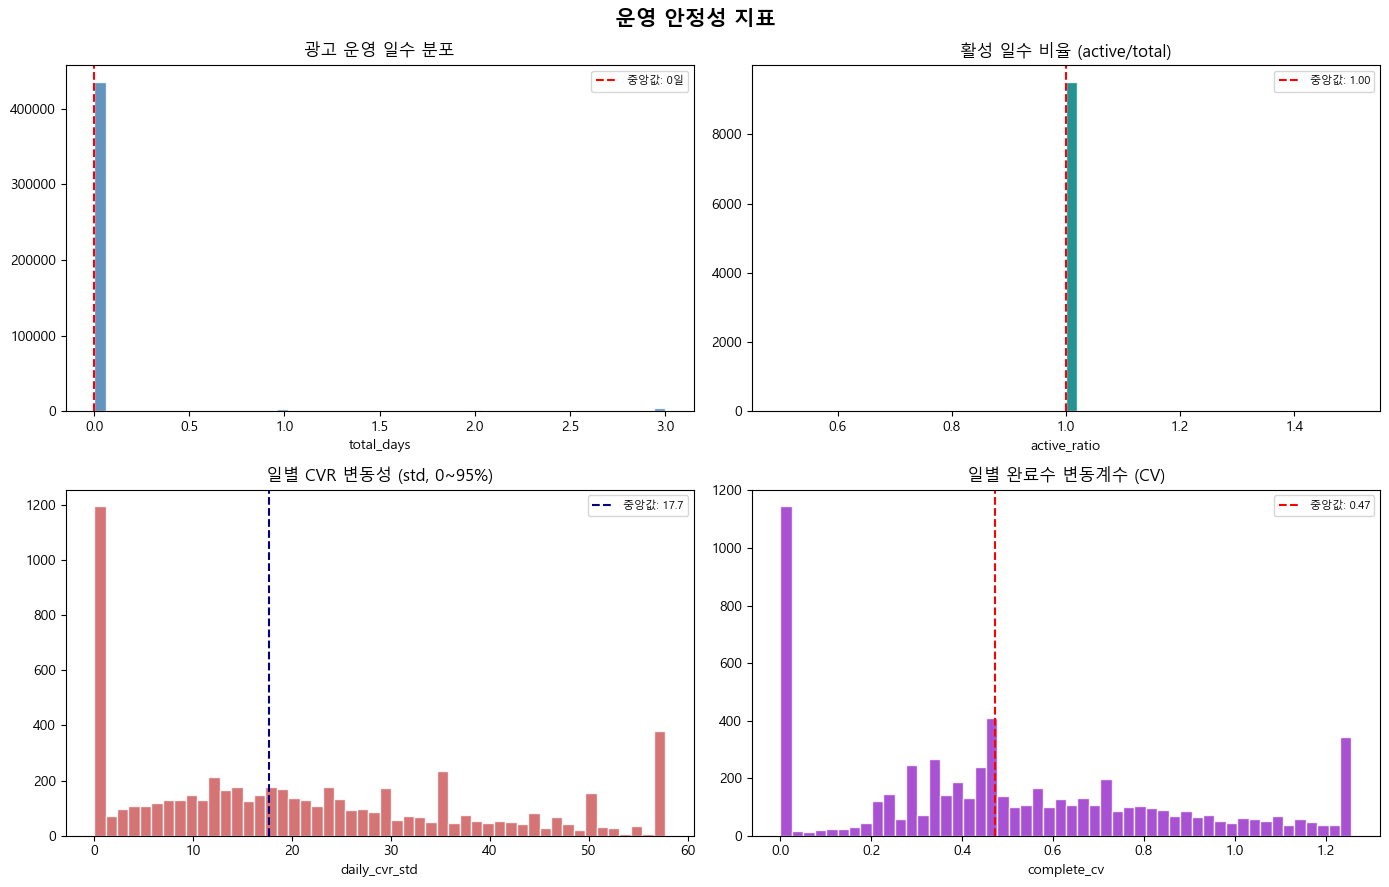

In [3]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("EDA 2. 운영 안정성 지표")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

sched['daily_cvr'] = np.where(
    sched['click_cnt'] > 0,
    sched['complete_cnt'] / sched['click_cnt'] * 100,
    np.nan
)
sched_agg = sched.groupby('ads_idx').agg(
    total_days    = ('click_date', 'count'),
    active_days   = ('is_click', 'sum'),
    mean_complete = ('complete_cnt', 'mean'),
    std_complete  = ('complete_cnt', 'std'),
    daily_cvr_std = ('daily_cvr', 'std'),
).reset_index()
sched_agg['active_ratio'] = sched_agg['active_days'] / sched_agg['total_days']
sched_agg['complete_cv']  = sched_agg['std_complete'] / (sched_agg['mean_complete'] + 1)

print("\n[운영 일수]")
print(sched_agg['total_days'].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(1))
print("\n[일별 CVR 변동성(std)]")
print(sched_agg['daily_cvr_std'].describe(percentiles=[.25,.5,.75,.9,.95]).round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('운영 안정성 지표', fontsize=15, fontweight='bold')

ax = axes[0, 0]
days_clip = sched_agg['total_days'].clip(0, sched_agg['total_days'].quantile(0.99))
ax.hist(days_clip, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(sched_agg['total_days'].median(), color='red', linestyle='--',
           label=f"중앙값: {sched_agg['total_days'].median():.0f}일")
ax.set_title('광고 운영 일수 분포')
ax.set_xlabel('total_days')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.hist(sched_agg['active_ratio'].dropna(), bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(sched_agg['active_ratio'].median(), color='red', linestyle='--',
           label=f"중앙값: {sched_agg['active_ratio'].median():.2f}")
ax.set_title('활성 일수 비율 (active/total)')
ax.set_xlabel('active_ratio')
ax.legend(fontsize=8)

ax = axes[1, 0]
cvr_std = sched_agg['daily_cvr_std'].dropna()
cvr_std_clip = cvr_std.clip(0, cvr_std.quantile(0.95))
ax.hist(cvr_std_clip, bins=50, color='indianred', edgecolor='white', alpha=0.85)
ax.axvline(cvr_std.median(), color='navy', linestyle='--',
           label=f"중앙값: {cvr_std.median():.1f}")
ax.set_title('일별 CVR 변동성 (std, 0~95%)')
ax.set_xlabel('daily_cvr_std')
ax.legend(fontsize=8)

ax = axes[1, 1]
cv = sched_agg['complete_cv'].dropna()
cv_clip = cv.clip(0, cv.quantile(0.95))
ax.hist(cv_clip, bins=50, color='darkorchid', edgecolor='white', alpha=0.85)
ax.axvline(cv.median(), color='red', linestyle='--',
           label=f"중앙값: {cv.median():.2f}")
ax.set_title('일별 완료수 변동계수 (CV)')
ax.set_xlabel('complete_cv')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EDA 3. 보정 CVR — 베이지안 스무딩 alpha 탐색
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
전체 평균 CVR: 45.02%


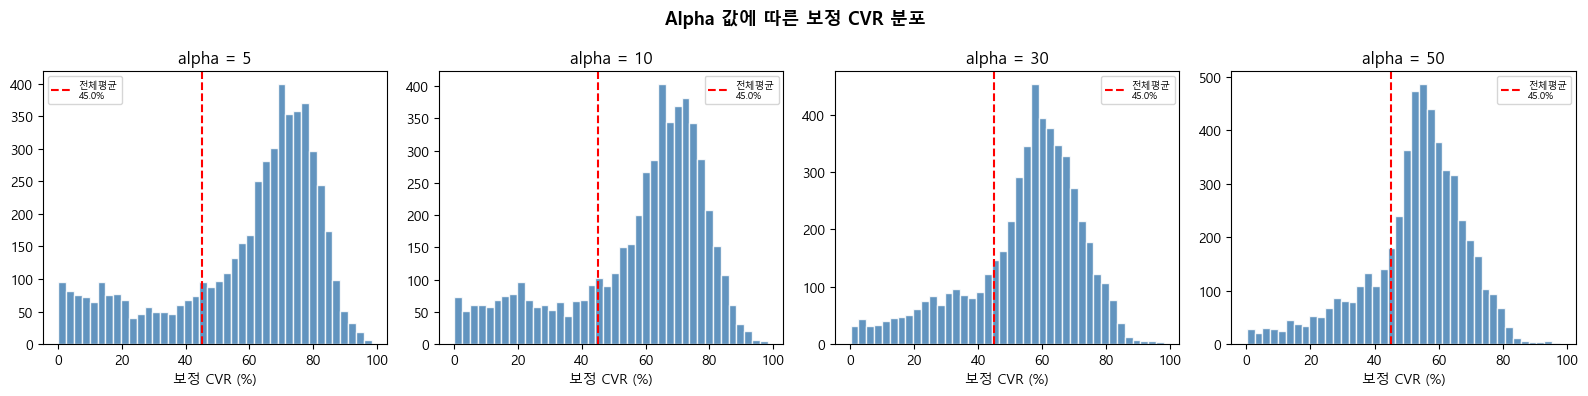

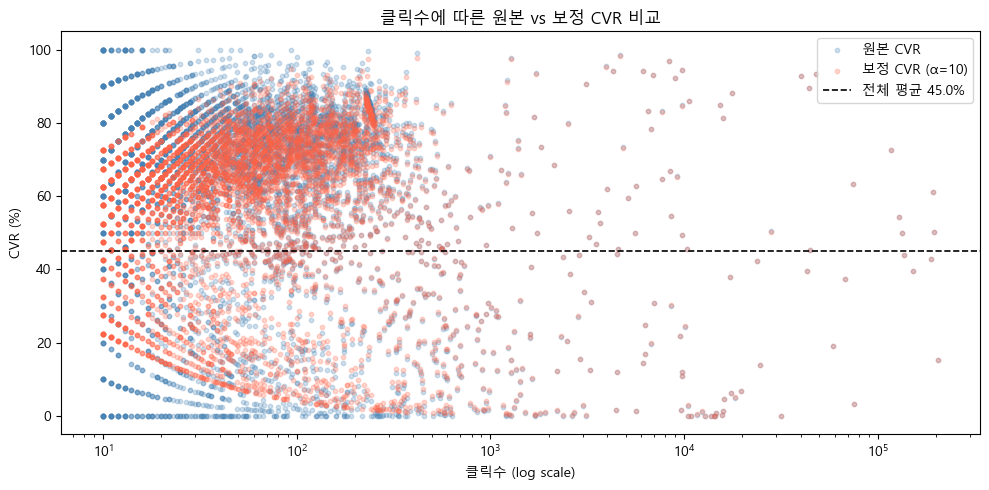

In [4]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("EDA 3. 보정 CVR — 베이지안 스무딩 alpha 탐색")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

v = valid[['ads_idx','click_cnt','complete_cnt','cvr_pct']].copy()
global_cvr = v['complete_cnt'].sum() / v['click_cnt'].sum()
print(f"전체 평균 CVR: {global_cvr*100:.2f}%")

alphas = [5, 10, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Alpha 값에 따른 보정 CVR 분포', fontsize=13, fontweight='bold')

for i, alpha in enumerate(alphas):
    smoothed = (v['complete_cnt'] + alpha * global_cvr) / (v['click_cnt'] + alpha)
    axes[i].hist(smoothed * 100, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(global_cvr * 100, color='red', linestyle='--',
                    label=f'전체평균\n{global_cvr*100:.1f}%')
    axes[i].set_title(f'alpha = {alpha}')
    axes[i].set_xlabel('보정 CVR (%)')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

# 클릭수별 보정 효과
alpha_best = 10
v['smoothed_cvr'] = (v['complete_cnt'] + alpha_best * global_cvr) / (v['click_cnt'] + alpha_best) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(v['click_cnt'], v['cvr_pct'], alpha=0.25, s=10, label='원본 CVR', color='steelblue')
ax.scatter(v['click_cnt'], v['smoothed_cvr'], alpha=0.25, s=10,
           label=f'보정 CVR (α={alpha_best})', color='tomato')
ax.axhline(global_cvr * 100, color='black', linestyle='--', linewidth=1.2,
           label=f'전체 평균 {global_cvr*100:.1f}%')
ax.set_xscale('log')
ax.set_xlabel('클릭수 (log scale)')
ax.set_ylabel('CVR (%)')
ax.set_title('클릭수에 따른 원본 vs 보정 CVR 비교')
ax.legend()
plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EDA 4. 조기 부진 기준 — 초기 N일 성과 분포
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[campaign_n_day 분포]
count    37314.0
mean       103.8
std        255.0
min          1.0
25%          3.0
50%          7.0
75%         50.0
90%        317.0
95%        591.3
99%       1358.0
max       1924.0
Name: campaign_n_day, dtype: float64
null 비율: 92.1%
값=0 비율: 0.0%


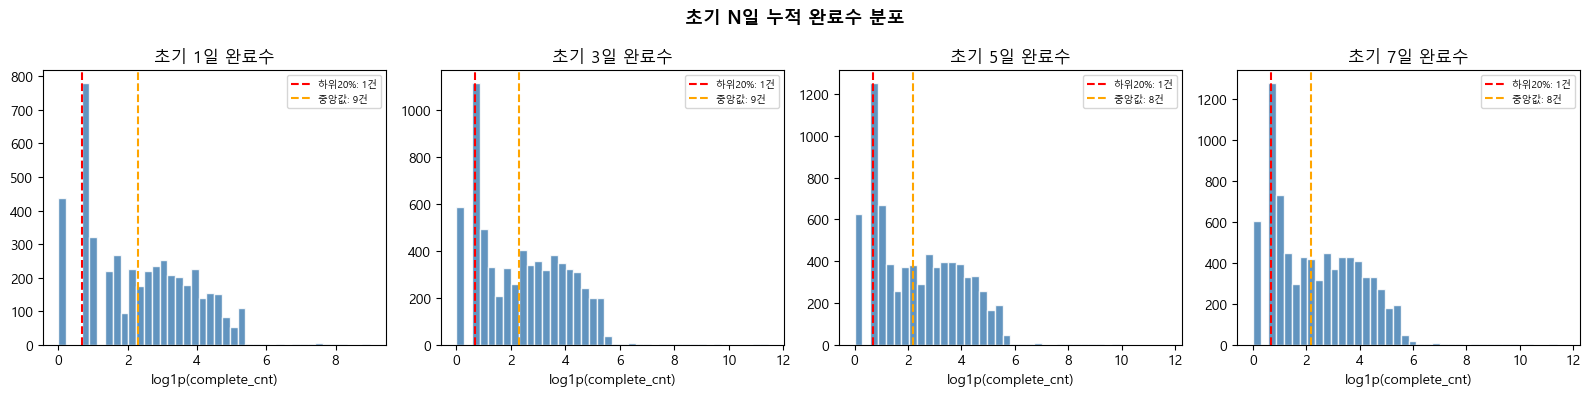


[유형별 초기 3일 완료수 분포]
ads_type_label  count  p20  median    p80
           설치형     40 63.0   609.5 6327.4
           참여형   6728  1.0     9.0   52.0


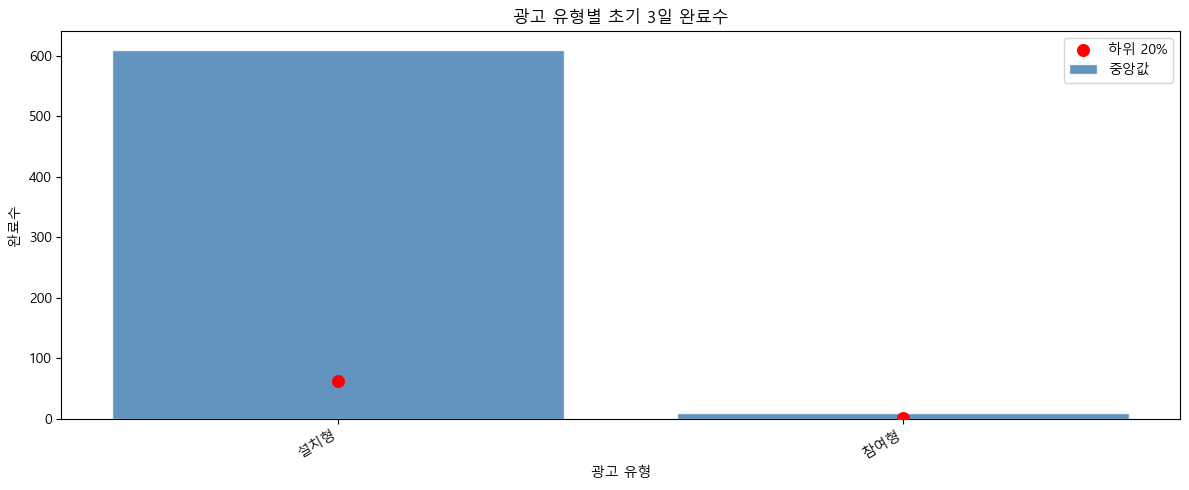

In [5]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("EDA 4. 조기 부진 기준 — 초기 N일 성과 분포")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

print("\n[campaign_n_day 분포]")
print(sched['campaign_n_day'].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(1))
print(f"null 비율: {sched['campaign_n_day'].isna().mean()*100:.1f}%")
print(f"값=0 비율: {(sched['campaign_n_day']==0).mean()*100:.1f}%")

# 초기 1/3/5/7일 완료수 분포
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('초기 N일 누적 완료수 분포', fontsize=13, fontweight='bold')

for i, n_day in enumerate([1, 3, 5, 7]):
    early = sched[sched['campaign_n_day'] <= n_day].groupby('ads_idx')['complete_cnt'].sum()
    p20   = early.quantile(0.20)
    med   = early.median()
    axes[i].hist(np.log1p(early), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(np.log1p(p20), color='red', linestyle='--',
                    label=f'하위20%: {p20:.0f}건')
    axes[i].axvline(np.log1p(med), color='orange', linestyle='--',
                    label=f'중앙값: {med:.0f}건')
    axes[i].set_title(f'초기 {n_day}일 완료수')
    axes[i].set_xlabel('log1p(complete_cnt)')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

# 유형별 초기 3일 완료수
early3 = (sched[sched['campaign_n_day'] <= 3]
          .groupby(['ads_idx','analysis_ads_type_label'])['complete_cnt']
          .sum().reset_index())
early3.columns = ['ads_idx','ads_type_label','complete_3d']

type_stats = (early3.groupby('ads_type_label')['complete_3d']
              .agg(count='count',
                   p20=lambda x: x.quantile(0.2),
                   median='median',
                   p80=lambda x: x.quantile(0.8))
              .reset_index())
type_stats = type_stats[type_stats['count'] >= 30].sort_values('median', ascending=False)
print("\n[유형별 초기 3일 완료수 분포]")
print(type_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
types   = type_stats['ads_type_label'].tolist()
medians = type_stats['median'].tolist()
p20s    = type_stats['p20'].tolist()
ax.bar(types, medians, color='steelblue', edgecolor='white', alpha=0.85, label='중앙값')
ax.scatter(types, p20s, color='red', zorder=5, s=70, label='하위 20%')
ax.set_title('광고 유형별 초기 3일 완료수')
ax.set_xlabel('광고 유형')
ax.set_ylabel('완료수')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EDA 5. 초기 3일 성과 → 최종 성과 예측력 검증
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

초기3일 완료수 vs 최종 완료수 상관계수: 0.675
초기3일 완료수 vs 최종 CVR 상관계수:   -0.001


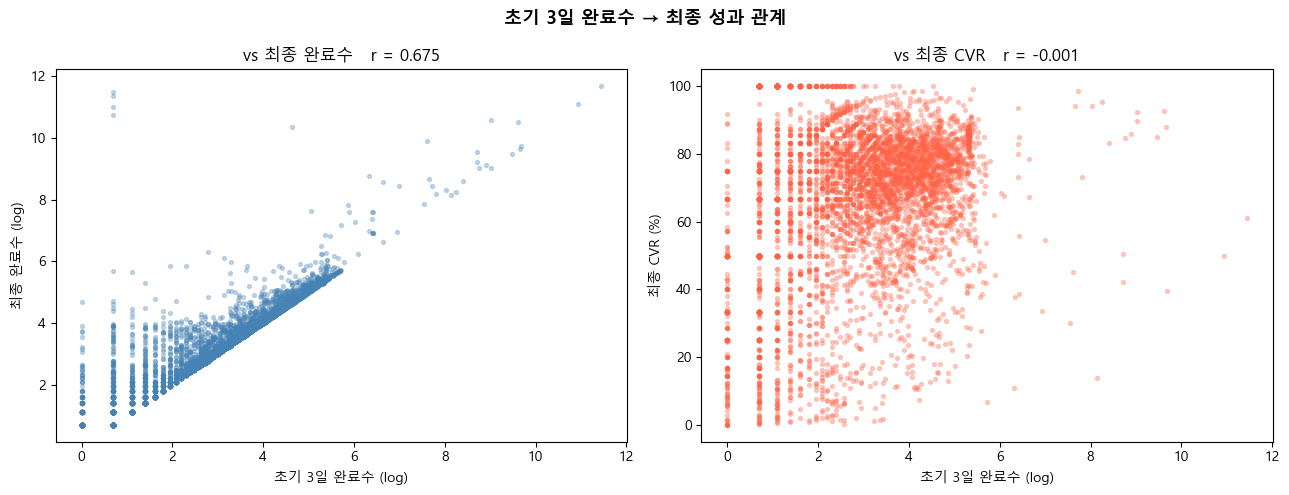

In [6]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("EDA 5. 초기 3일 성과 → 최종 성과 예측력 검증")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

early3_cnt = (sched[sched['campaign_n_day'] <= 3]
              .groupby('ads_idx')['complete_cnt'].sum()
              .reset_index(name='complete_3d'))
total_cnt  = (sched.groupby('ads_idx')['complete_cnt'].sum()
              .reset_index(name='complete_total'))

merge = (early3_cnt
         .merge(total_cnt, on='ads_idx')
         .merge(ad_outcome[['ads_idx','cvr_pct','click_cnt']].dropna(), on='ads_idx'))
merge = merge[merge['complete_total'] > 0]

corr_total = merge[['complete_3d','complete_total']].corr().iloc[0,1]
corr_cvr   = merge[['complete_3d','cvr_pct']].corr().iloc[0,1]
print(f"\n초기3일 완료수 vs 최종 완료수 상관계수: {corr_total:.3f}")
print(f"초기3일 완료수 vs 최종 CVR 상관계수:   {corr_cvr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('초기 3일 완료수 → 최종 성과 관계', fontsize=13, fontweight='bold')

axes[0].scatter(np.log1p(merge['complete_3d']), np.log1p(merge['complete_total']),
                alpha=0.3, s=8, color='steelblue')
axes[0].set_xlabel('초기 3일 완료수 (log)')
axes[0].set_ylabel('최종 완료수 (log)')
axes[0].set_title(f'vs 최종 완료수   r = {corr_total:.3f}')

axes[1].scatter(np.log1p(merge['complete_3d']), merge['cvr_pct'],
                alpha=0.3, s=8, color='tomato')
axes[1].set_xlabel('초기 3일 완료수 (log)')
axes[1].set_ylabel('최종 CVR (%)')
axes[1].set_title(f'vs 최종 CVR   r = {corr_cvr:.3f}')

plt.tight_layout()
plt.show()




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EDA 6. 이상치 탐색
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CVR≥99.9% 광고:       53건  (1.0%)
클릭수 99%tile:        8,988건
클릭수 > p99 광고:     53건
총 마진 음수 광고:     107건  (1.3%)
완료수 > 클릭수 광고: 0건


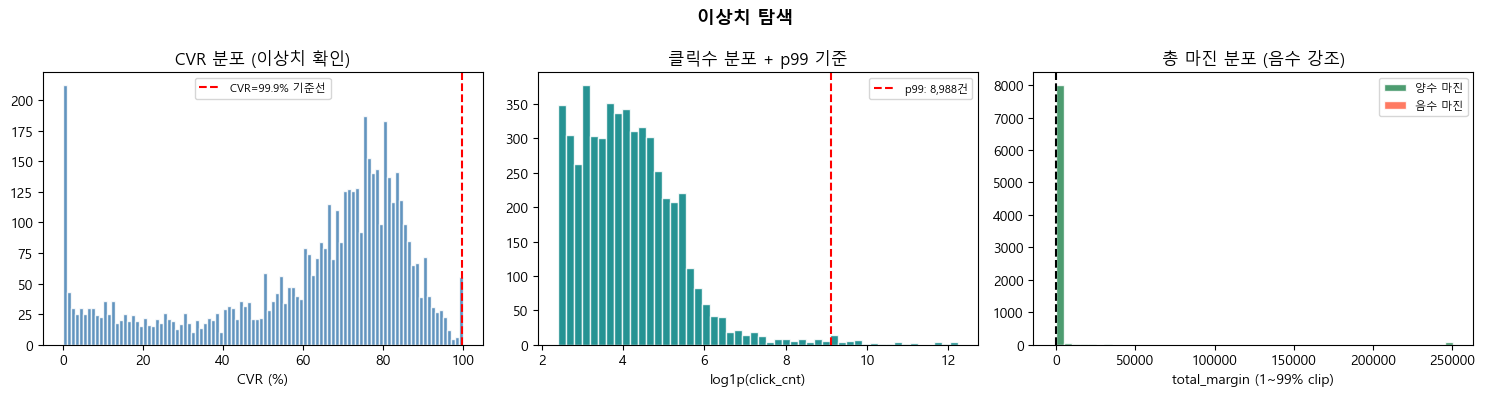

In [7]:
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("EDA 6. 이상치 탐색")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

cvr100       = valid[valid['cvr_pct'] >= 99.9]
click_p99    = valid['click_cnt'].quantile(0.99)
neg_margin   = fin_agg[fin_agg['total_margin'] < 0]
anomaly_comp = valid[valid['complete_cnt'] > valid['click_cnt']]

print(f"\nCVR≥99.9% 광고:       {len(cvr100):,}건  ({len(cvr100)/len(valid)*100:.1f}%)")
print(f"클릭수 99%tile:        {click_p99:,.0f}건")
print(f"클릭수 > p99 광고:     {(valid['click_cnt']>click_p99).sum():,}건")
print(f"총 마진 음수 광고:     {len(neg_margin):,}건  ({len(neg_margin)/len(fin_agg)*100:.1f}%)")
print(f"완료수 > 클릭수 광고: {len(anomaly_comp):,}건")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('이상치 탐색', fontsize=13, fontweight='bold')

# CVR 극단값 확대
ax = axes[0]
ax.hist(valid['cvr_pct'].dropna(), bins=100, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(99.9, color='red', linestyle='--', linewidth=1.5, label='CVR=99.9% 기준선')
ax.set_title('CVR 분포 (이상치 확인)')
ax.set_xlabel('CVR (%)')
ax.legend(fontsize=8)

# 클릭수 분포 + p99 표시
ax = axes[1]
ax.hist(np.log1p(valid['click_cnt']), bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(np.log1p(click_p99), color='red', linestyle='--',
           label=f'p99: {click_p99:,.0f}건')
ax.set_title('클릭수 분포 + p99 기준')
ax.set_xlabel('log1p(click_cnt)')
ax.legend(fontsize=8)

# 마진 분포 (음수 강조)
ax = axes[2]
margin_clip = fin_agg['total_margin'].clip(fin_agg['total_margin'].quantile(0.01),
                                            fin_agg['total_margin'].quantile(0.99))
ax.hist(margin_clip[fin_agg['total_margin'] >= 0], bins=50,
        color='seagreen', edgecolor='white', alpha=0.85, label='양수 마진')
ax.hist(margin_clip[fin_agg['total_margin'] < 0], bins=20,
        color='tomato', edgecolor='white', alpha=0.85, label='음수 마진')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_title('총 마진 분포 (음수 강조)')
ax.set_xlabel('total_margin (1~99% clip)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
print("\n\n" + "="*55)
print("✅ EDA 완료 — 기준 설정 포인트 요약")
print("="*55)
print(f"""
[품질 점수 설계]
  유효 광고 기준  : 클릭수 >= 10  ({len(valid):,}건)
  전체 평균 CVR   : {global_cvr*100:.2f}%
  CVR 중앙값      : {valid['cvr_pct'].median():.1f}%
  CVR 75%tile     : {valid['cvr_pct'].quantile(0.75):.1f}%
  보정 CVR alpha  : 10 추천

[조기 부진 기준 후보]
  초기 기준일     : 3일 vs 5일  →  EDA 4-A 차트로 판단
  그룹핑 기준     : (analysis_ads_type_label, reward_band)
  부진 임계값     : 그룹 내 하위 20%  or  기대값의 50% 미만

[이상치 Flag 후보]
  CVR >= 99.9%
  클릭수 > {click_p99:,.0f} (p99)
  총 마진 < 0
  완료수 > 클릭수
""")



✅ EDA 완료 — 기준 설정 포인트 요약

[품질 점수 설계]
  유효 광고 기준  : 클릭수 >= 10  (5,281건)
  전체 평균 CVR   : 45.02%
  CVR 중앙값      : 70.0%
  CVR 75%tile     : 80.0%
  보정 CVR alpha  : 10 추천

[조기 부진 기준 후보]
  초기 기준일     : 3일 vs 5일  →  EDA 4-A 차트로 판단
  그룹핑 기준     : (analysis_ads_type_label, reward_band)
  부진 임계값     : 그룹 내 하위 20%  or  기대값의 50% 미만

[이상치 Flag 후보]
  CVR >= 99.9%
  클릭수 > 8,988 (p99)
  총 마진 < 0
  완료수 > 클릭수



In [9]:
# ── 중간 확인 ────────────────────────────────────────────────
print(f"master: {len(master):,}건")
print(f"smoothed_cvr: {'smoothed_cvr' in valid.columns}")
print(f"elapsed_day: {'elapsed_day' in sched2.columns}")


master: 5,281건
smoothed_cvr: False
elapsed_day: True




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
추가 EDA A-1. 품질 지표 간 상관행렬
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           보정CVR  총마진(log)   단위마진    마진율  완료수(log)  클릭수(log)  CTIT(log)
보정CVR      1.000     0.088 -0.053 -0.245     0.443    -0.066     -0.513
총마진(log)   0.088     1.000  0.262  0.279     0.665     0.736     -0.001
단위마진      -0.053     0.262  1.000  0.348     0.022     0.071      0.030
마진율       -0.245     0.279  0.348  1.000    -0.110     0.025      0.183
완료수(log)   0.443     0.665  0.022 -0.110     1.000     0.795     -0.158
클릭수(log)  -0.066     0.736  0.071  0.025     0.795     1.000      0.182
CTIT(log) -0.513    -0.001  0.030  0.183    -0.158     0.182      1.000


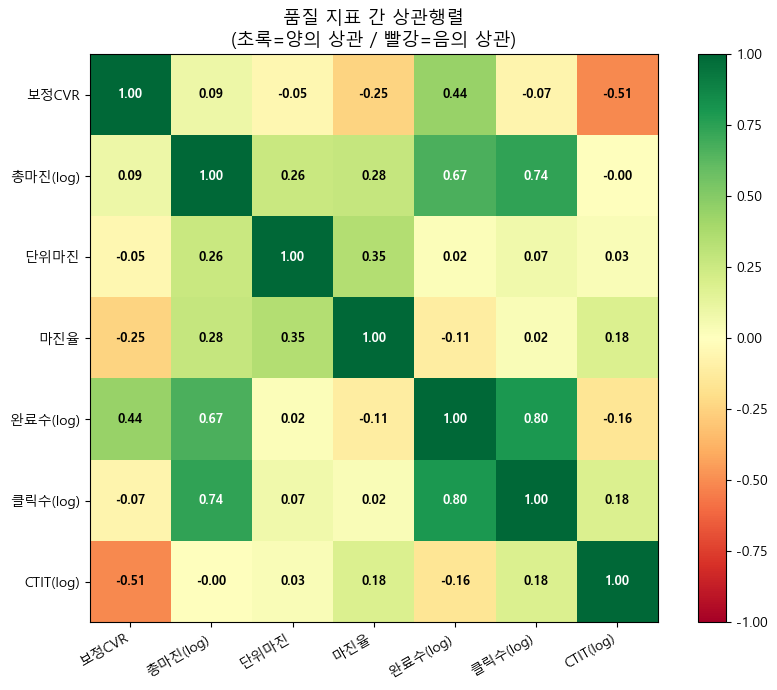

In [10]:
# ══════════════════════════════════════════════════════
# 추가 EDA A-1. 품질 지표 간 상관행렬
# ══════════════════════════════════════════════════════
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("추가 EDA A-1. 품질 지표 간 상관행렬")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

corr_cols = {
    '보정CVR'    : 'smoothed_cvr',
    '총마진(log)': 'total_margin',
    '단위마진'   : 'margin_per_complete',
    '마진율'     : 'margin_rate',
    '완료수(log)': 'complete_cnt_f',
    '클릭수(log)': 'click_cnt',
    'CTIT(log)'  : 'avg_ctit',
}

corr_df = master[list(corr_cols.values())].copy()
corr_df['total_margin']   = np.log1p(corr_df['total_margin'].clip(lower=0))
corr_df['complete_cnt_f'] = np.log1p(corr_df['complete_cnt_f'])
corr_df['click_cnt']      = np.log1p(corr_df['click_cnt'])
corr_df['avg_ctit']       = np.log1p(corr_df['avg_ctit'].clip(lower=0))
corr_df.columns = list(corr_cols.keys())

corr_matrix = corr_df.corr()
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
labels = list(corr_cols.keys())
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold')
ax.set_title('품질 지표 간 상관행렬\n(초록=양의 상관 / 빨강=음의 상관)', fontsize=13)
plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
추가 EDA A-2. 광고 유형별 지표 분포
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


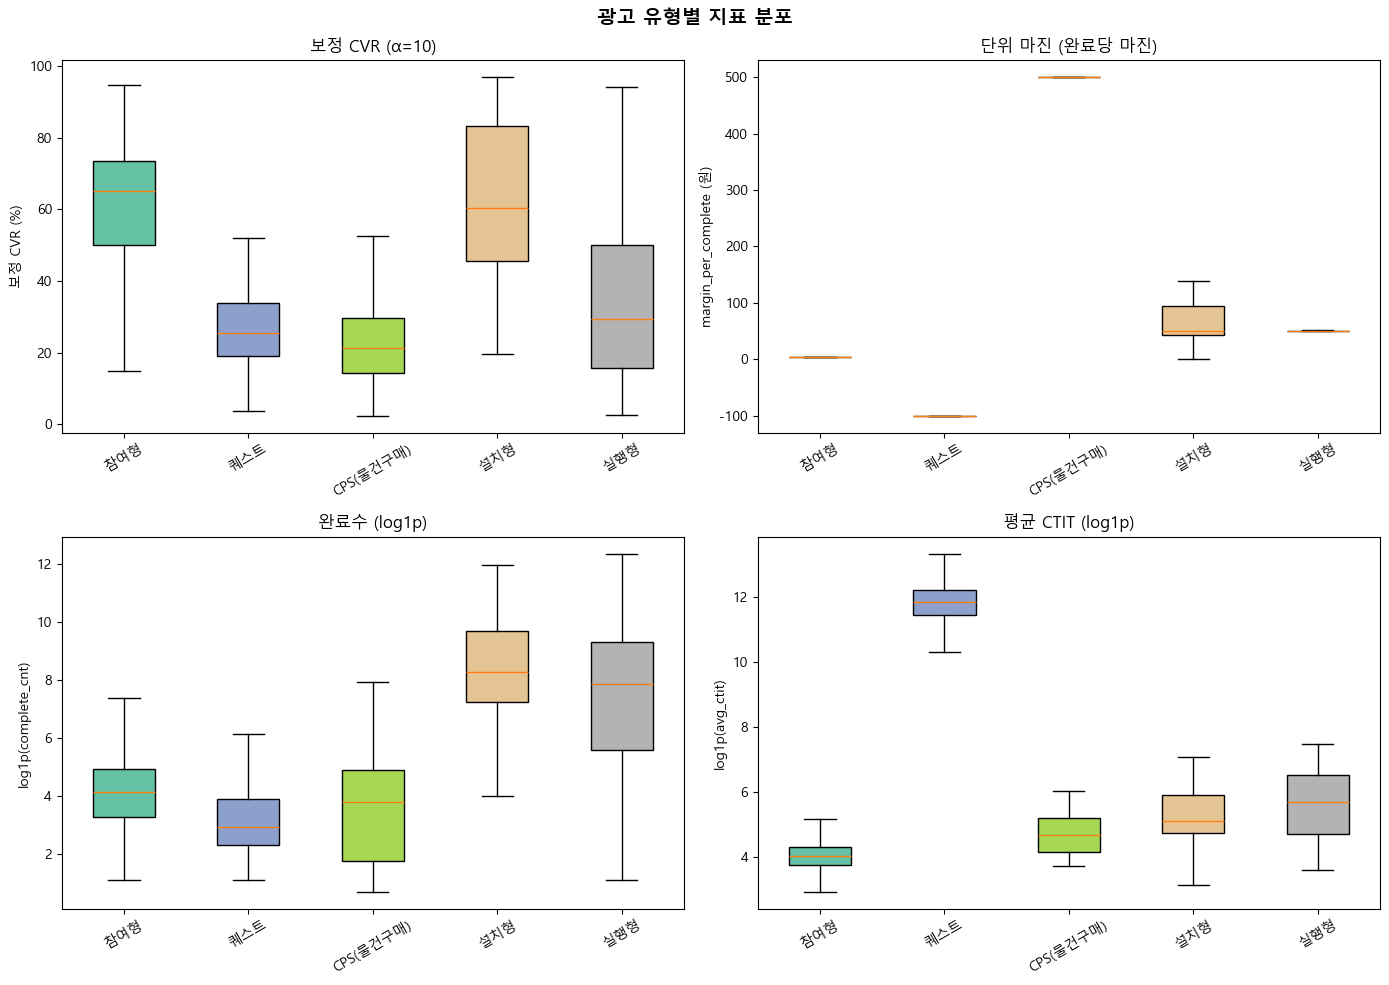

In [11]:
# ══════════════════════════════════════════════════════
# 추가 EDA A-2. 유형별 각 지표 분포 (boxplot)
# ══════════════════════════════════════════════════════
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("추가 EDA A-2. 광고 유형별 지표 분포")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# 샘플 충분한 유형만
type_counts = master['analysis_ads_type_label'].value_counts()
valid_types = type_counts[type_counts >= 30].index.tolist()
m = master[master['analysis_ads_type_label'].isin(valid_types)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('광고 유형별 지표 분포', fontsize=14, fontweight='bold')

# 보정 CVR
ax = axes[0, 0]
groups = [m[m['analysis_ads_type_label']==t]['smoothed_cvr'].dropna() for t in valid_types]
bp = ax.boxplot(groups, labels=valid_types, patch_artist=True, showfliers=False)
colors = plt.cm.Set2(np.linspace(0, 1, len(valid_types)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('보정 CVR (α=10)')
ax.set_ylabel('보정 CVR (%)')
ax.tick_params(axis='x', rotation=30)

# 단위 마진
ax = axes[0, 1]
groups = [m[m['analysis_ads_type_label']==t]['margin_per_complete']
          .clip(-100, 500).dropna() for t in valid_types]
bp = ax.boxplot(groups, labels=valid_types, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('단위 마진 (완료당 마진)')
ax.set_ylabel('margin_per_complete (원)')
ax.tick_params(axis='x', rotation=30)

# 완료수 (log)
ax = axes[1, 0]
groups = [np.log1p(m[m['analysis_ads_type_label']==t]['complete_cnt_f'].dropna())
          for t in valid_types]
bp = ax.boxplot(groups, labels=valid_types, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('완료수 (log1p)')
ax.set_ylabel('log1p(complete_cnt)')
ax.tick_params(axis='x', rotation=30)

# CTIT (log)
ax = axes[1, 1]
groups = [np.log1p(m[m['analysis_ads_type_label']==t]['avg_ctit'].clip(lower=0).dropna())
          for t in valid_types]
bp = ax.boxplot(groups, labels=valid_types, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('평균 CTIT (log1p)')
ax.set_ylabel('log1p(avg_ctit)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
추가 EDA A-3. 실제 운영 기간 분포 (ad_attr 기반)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

무기한 광고(edate=9999): 430,501건 (96.7%)

[운영 기간 분포 (일)]
count    444877.0
mean        203.4
std         252.4
min           0.0
10%          33.0
25%         106.0
50%         122.0
75%         242.0
90%         404.0
95%         472.0
99%        1469.5
max        3165.0
Name: op_days, dtype: float64

유효 광고 중 운영 기간 계산 가능: 5,281건
count    5280.0
mean       31.6
std       146.6
min         0.0
25%         0.0
50%         0.0
75%         5.0
90%        13.0
95%       154.0
max      1857.0
Name: op_days, dtype: float64


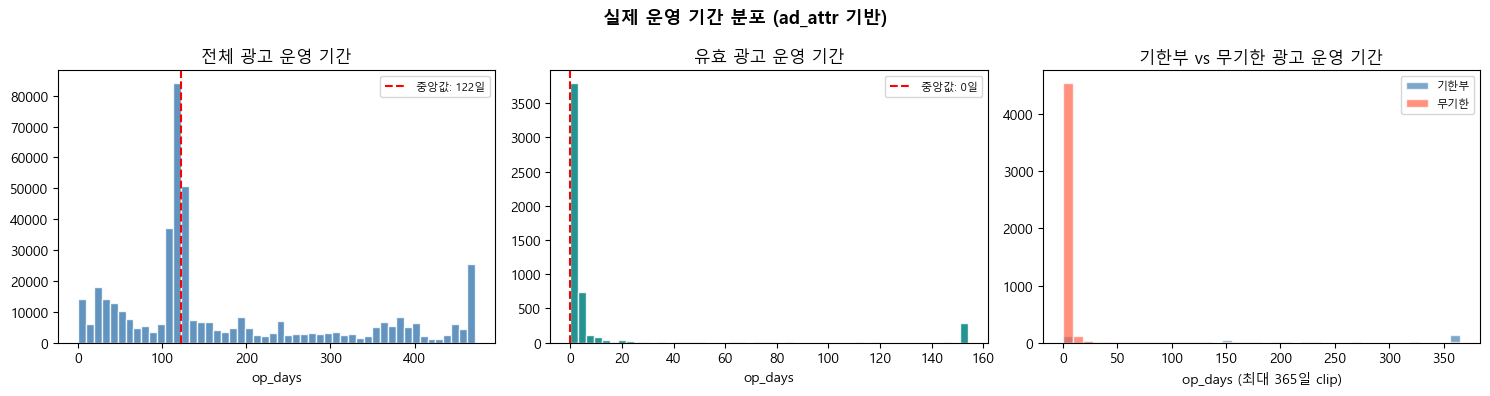

In [12]:
# ══════════════════════════════════════════════════════
# 추가 EDA A-3. 운영 기간 재계산 (ad_attr sdate/edate)
# ══════════════════════════════════════════════════════
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("추가 EDA A-3. 실제 운영 기간 분포 (ad_attr 기반)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

attr = ad_attr.copy()
attr['ads_sdate'] = pd.to_datetime(attr['ads_sdate'])
attr['ads_edate'] = pd.to_datetime(attr['ads_edate'])

# 9999년 종료일 = 무기한 광고 → 현재 기준으로 경과일 계산
today = pd.Timestamp('2025-08-01')  # 데이터 기준 최신 날짜
attr['edate_adj'] = attr['ads_edate'].clip(upper=today)
attr['op_days']   = (attr['edate_adj'] - attr['ads_sdate']).dt.days.clip(lower=0)
attr['is_infinite'] = (attr['ads_edate'].dt.year == 9999).astype(int)

print(f"\n무기한 광고(edate=9999): {attr['is_infinite'].sum():,}건 "
      f"({attr['is_infinite'].mean()*100:.1f}%)")
print("\n[운영 기간 분포 (일)]")
print(attr['op_days'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).round(1))

# 유효 광고와 join
attr_valid = attr[attr['ads_idx'].isin(valid['ads_idx'])].copy()
print(f"\n유효 광고 중 운영 기간 계산 가능: {len(attr_valid):,}건")
print(attr_valid['op_days'].describe(percentiles=[.25,.5,.75,.9,.95]).round(1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('실제 운영 기간 분포 (ad_attr 기반)', fontsize=13, fontweight='bold')

# 전체 운영 기간
ax = axes[0]
op_clip = attr['op_days'].clip(0, attr['op_days'].quantile(0.95))
ax.hist(op_clip, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(attr['op_days'].median(), color='red', linestyle='--',
           label=f"중앙값: {attr['op_days'].median():.0f}일")
ax.set_title('전체 광고 운영 기간')
ax.set_xlabel('op_days')
ax.legend(fontsize=8)

# 유효 광고 운영 기간
ax = axes[1]
op_valid_clip = attr_valid['op_days'].clip(0, attr_valid['op_days'].quantile(0.95))
ax.hist(op_valid_clip, bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(attr_valid['op_days'].median(), color='red', linestyle='--',
           label=f"중앙값: {attr_valid['op_days'].median():.0f}일")
ax.set_title('유효 광고 운영 기간')
ax.set_xlabel('op_days')
ax.legend(fontsize=8)

# 무기한 vs 기한부 운영 기간 비교
ax = axes[2]
finite  = attr_valid[attr_valid['is_infinite']==0]['op_days'].clip(0, 365)
infinite= attr_valid[attr_valid['is_infinite']==1]['op_days'].clip(0, 365)
ax.hist(finite,   bins=40, color='steelblue', edgecolor='white', alpha=0.7, label='기한부')
ax.hist(infinite, bins=40, color='tomato',    edgecolor='white', alpha=0.7, label='무기한')
ax.set_title('기한부 vs 무기한 광고 운영 기간')
ax.set_xlabel('op_days (최대 365일 clip)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
추가 EDA B-1. elapsed_day 분포 확인
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[elapsed_day 분포]
count    37314.0
mean       101.8
std        255.0
min         -1.0
25%          1.0
50%          5.0
75%         48.0
90%        315.0
95%        589.3
99%       1356.0
max       1922.0
Name: elapsed_day, dtype: float64

elapsed_day < 0 (오류): 4,741건
elapsed_day = 0 (시작일): 3,757건

[초기 N일 데이터 보유 광고 수]
  elapsed_day < 1일 데이터 보유 광고: 3,757건
  elapsed_day < 3일 데이터 보유 광고: 5,181건
  elapsed_day < 5일 데이터 보유 광고: 5,815건
  elapsed_day < 7일 데이터 보유 광고: 6,155건


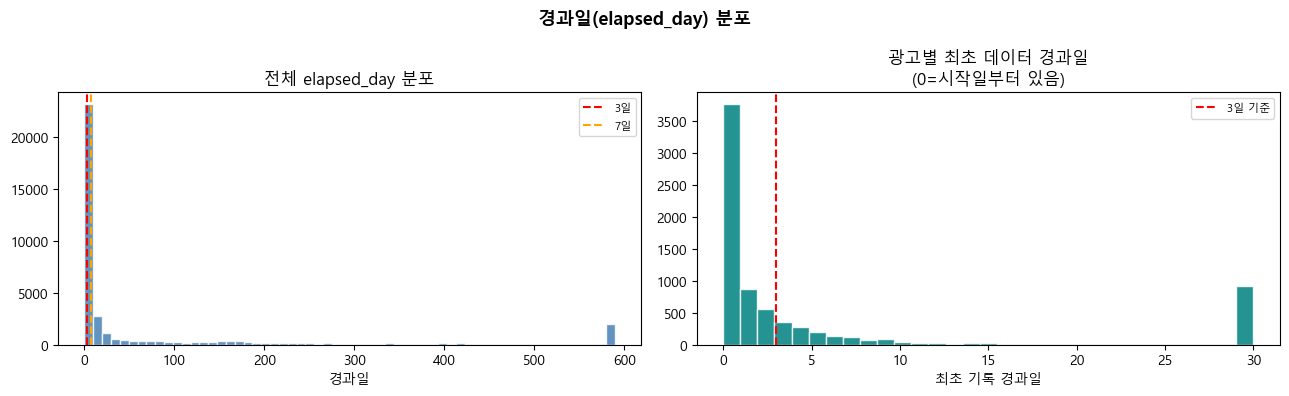


✅ sched2 생성 완료
shape: (473066, 24)


In [13]:
# ── 추가 EDA B-1. elapsed_day 분포 ──────────────────────────
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("추가 EDA B-1. elapsed_day 분포 확인")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

print("[elapsed_day 분포]")
print(sched2['elapsed_day'].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(1))
print(f"\nelapsed_day < 0 (오류): {(sched2['elapsed_day'] < 0).sum():,}건")
print(f"elapsed_day = 0 (시작일): {(sched2['elapsed_day'] == 0).sum():,}건")

print("\n[초기 N일 데이터 보유 광고 수]")
for n in [1, 3, 5, 7]:
    cnt = sched2[(sched2['elapsed_day'] >= 0) & (sched2['elapsed_day'] < n)]['ads_idx'].nunique()
    print(f"  elapsed_day < {n}일 데이터 보유 광고: {cnt:,}건")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('경과일(elapsed_day) 분포', fontsize=13, fontweight='bold')

ax = axes[0]
ed_clip = sched2['elapsed_day'].clip(0, sched2['elapsed_day'].quantile(0.95))
ax.hist(ed_clip, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
for n, c in zip([3, 7], ['red', 'orange']):
    ax.axvline(n, color=c, linestyle='--', label=f'{n}일')
ax.set_title('전체 elapsed_day 분포')
ax.set_xlabel('경과일')
ax.legend(fontsize=8)

ax = axes[1]
first_day = (sched2[sched2['elapsed_day'] >= 0]
             .groupby('ads_idx')['elapsed_day'].min()
             .reset_index(name='first_day'))
ax.hist(first_day['first_day'].clip(0, 30), bins=31,
        color='teal', edgecolor='white', alpha=0.85)
ax.axvline(3, color='red', linestyle='--', label='3일 기준')
ax.set_title('광고별 최초 데이터 경과일\n(0=시작일부터 있음)')
ax.set_xlabel('최초 기록 경과일')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ sched2 생성 완료")
print(f"shape: {sched2.shape}")

In [14]:
print(valid.columns.tolist())
print('smoothed_cvr' in valid.columns)

['ads_idx', 'ads_name', 'ads_type', 'ads_category', 'ads_reward_price', 'ads_order', 'ads_rejoin_type', 'click_cnt', 'complete_cnt', 'avg_ctit', 'total_reward_cost', 'is_avg_ctit_null', 'is_total_reward_cost_null', 'is_top_exposure', 'exposure_grade', 'ads_type_label', 'category_name', 'reward_band', 'analysis_ads_type_label', 'analysis_ads_type_source', 'cvr_pct', 'is_valid_click10']
False


In [15]:
global_cvr = valid['complete_cnt'].sum() / valid['click_cnt'].sum()
valid['smoothed_cvr'] = (
    (valid['complete_cnt'] + 10 * global_cvr) / (valid['click_cnt'] + 10) * 100
)
print('smoothed_cvr' in valid.columns)  # True 뜨면 성공

True




━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
추가 EDA B-2. 초기 N일 CVR vs 최종 CVR 상관
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
초기 1일 CVR → 최종 CVR: r=0.853  |  보정CVR: r=0.829  (샘플 2,337건)
초기 3일 CVR → 최종 CVR: r=0.910  |  보정CVR: r=0.880  (샘플 2,909건)
초기 5일 CVR → 최종 CVR: r=0.929  |  보정CVR: r=0.899  (샘플 3,140건)
초기 7일 CVR → 최종 CVR: r=0.941  |  보정CVR: r=0.911  (샘플 3,299건)


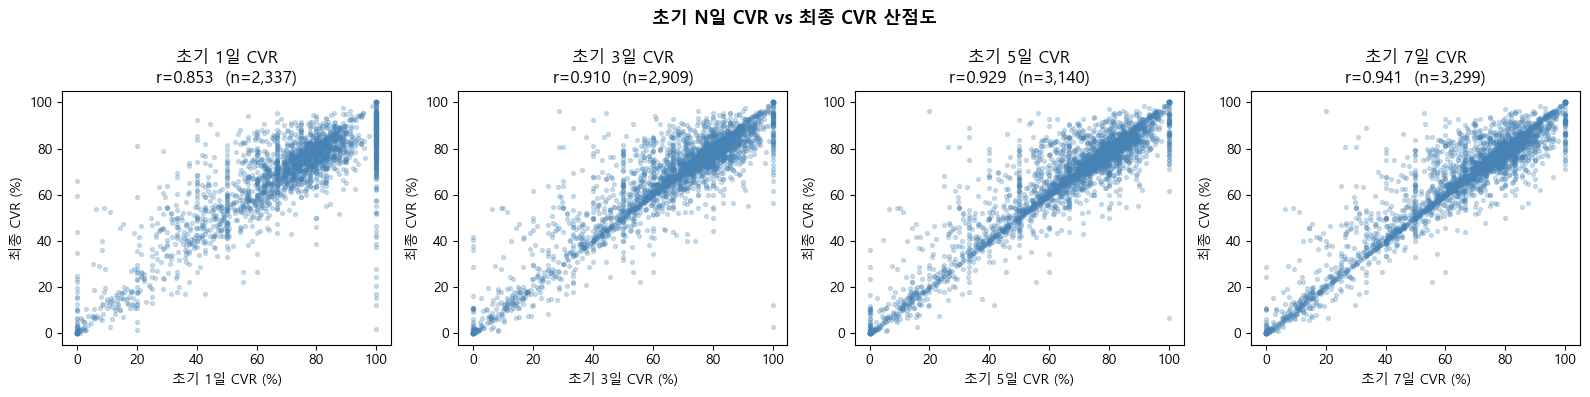

In [16]:
# ══════════════════════════════════════════════════════
# B-2. 초기 N일 CVR vs 최종 CVR 상관
# ══════════════════════════════════════════════════════
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("추가 EDA B-2. 초기 N일 CVR vs 최종 CVR 상관")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

for n in [1, 3, 5, 7]:
    early = (sched2[(sched2['elapsed_day'] >= 0) & (sched2['elapsed_day'] < n)]
             .groupby('ads_idx').agg(
                 early_click    = ('click_cnt', 'sum'),
                 early_complete = ('complete_cnt', 'sum'),
             ).reset_index())
    early['early_cvr'] = np.where(
        early['early_click'] >= 5,
        early['early_complete'] / early['early_click'] * 100,
        np.nan
    )
    merged = (early
              .merge(valid[['ads_idx','cvr_pct','smoothed_cvr']], on='ads_idx', how='inner')
              .dropna(subset=['early_cvr','cvr_pct']))

    r_raw      = merged[['early_cvr','cvr_pct']].corr().iloc[0,1]
    r_smoothed = merged[['early_cvr','smoothed_cvr']].corr().iloc[0,1]
    print(f"초기 {n}일 CVR → 최종 CVR: r={r_raw:.3f}  |  보정CVR: r={r_smoothed:.3f}  "
          f"(샘플 {len(merged):,}건)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('초기 N일 CVR vs 최종 CVR 산점도', fontsize=13, fontweight='bold')

for i, n in enumerate([1, 3, 5, 7]):
    early = (sched2[(sched2['elapsed_day'] >= 0) & (sched2['elapsed_day'] < n)]
             .groupby('ads_idx').agg(
                 early_click    = ('click_cnt', 'sum'),
                 early_complete = ('complete_cnt', 'sum'),
             ).reset_index())
    early['early_cvr'] = np.where(
        early['early_click'] >= 5,
        early['early_complete'] / early['early_click'] * 100,
        np.nan
    )
    merged = (early
              .merge(valid[['ads_idx','cvr_pct']], on='ads_idx', how='inner')
              .dropna(subset=['early_cvr','cvr_pct']))

    r = merged[['early_cvr','cvr_pct']].corr().iloc[0,1]
    axes[i].scatter(merged['early_cvr'], merged['cvr_pct'],
                    alpha=0.25, s=8, color='steelblue')
    axes[i].set_title(f'초기 {n}일 CVR\nr={r:.3f}  (n={len(merged):,})')
    axes[i].set_xlabel(f'초기 {n}일 CVR (%)')
    axes[i].set_ylabel('최종 CVR (%)')

plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
추가 EDA B-3. 유형별 초기 3일 CVR 분포 → 부진 임계값 탐색
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[유형별 초기 3일 CVR 기술 통계]
analysis_ads_type_label  count       p20    median       p80
                    참여형   2853 50.000000 71.641791 83.333333
                    설치형     35 42.872092 65.476190 87.000149

[reward_band별 초기 3일 CVR 기술 통계]
reward_band  count       p20    median       p80
     50원 미만   2780 52.000000 72.302019 83.333333
   100~299원     66 10.367893 41.519291 75.166297
    500원 이상     57  0.000000  0.000000  6.350282


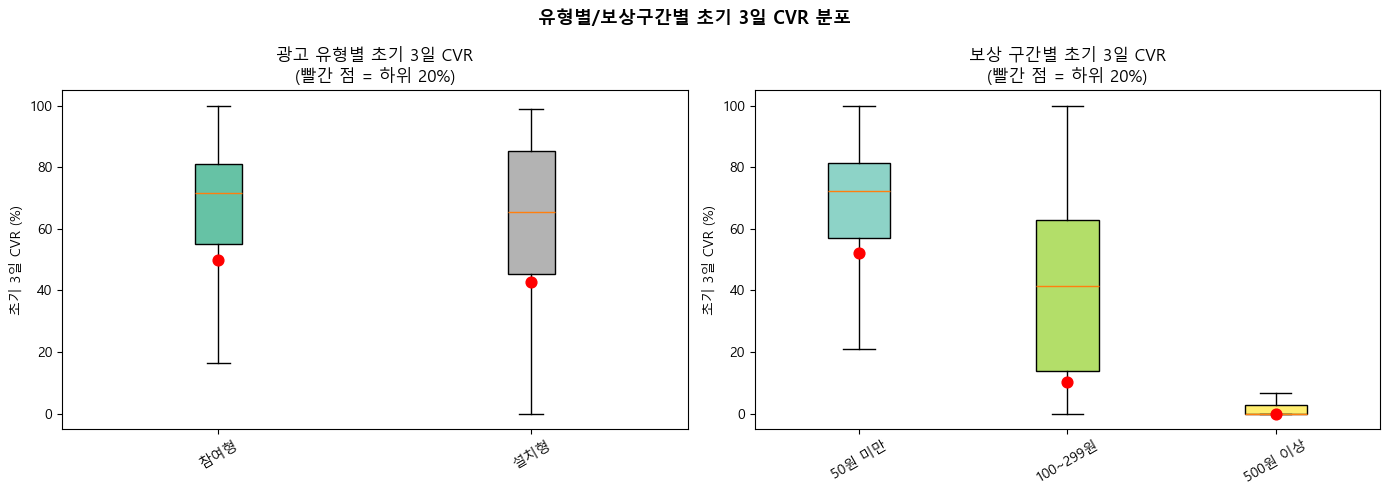

In [17]:
# ══════════════════════════════════════════════════════
# B-3. 유형별 초기 3일 CVR 분포 → 부진 임계값
# ══════════════════════════════════════════════════════
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("추가 EDA B-3. 유형별 초기 3일 CVR 분포 → 부진 임계값 탐색")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

early3 = (sched2[(sched2['elapsed_day'] >= 0) & (sched2['elapsed_day'] < 3)]
          .groupby('ads_idx').agg(
              early_click    = ('click_cnt', 'sum'),
              early_complete = ('complete_cnt', 'sum'),
          ).reset_index())
early3['early_cvr'] = np.where(
    early3['early_click'] >= 5,
    early3['early_complete'] / early3['early_click'] * 100,
    np.nan
)
early3 = (early3
          .merge(valid[['ads_idx','analysis_ads_type_label','reward_band',
                         'cvr_pct','smoothed_cvr']],
                 on='ads_idx', how='inner')
          .dropna(subset=['early_cvr']))

print("\n[유형별 초기 3일 CVR 기술 통계]")
type_cvr = (early3.groupby('analysis_ads_type_label')['early_cvr']
            .agg(count='count',
                 p20=lambda x: x.quantile(0.2),
                 median='median',
                 p80=lambda x: x.quantile(0.8))
            .reset_index())
type_cvr = type_cvr[type_cvr['count'] >= 20].sort_values('median', ascending=False)
print(type_cvr.to_string(index=False))

print("\n[reward_band별 초기 3일 CVR 기술 통계]")
band_cvr = (early3.groupby('reward_band')['early_cvr']
            .agg(count='count',
                 p20=lambda x: x.quantile(0.2),
                 median='median',
                 p80=lambda x: x.quantile(0.8))
            .reset_index())
band_cvr = band_cvr[band_cvr['count'] >= 20].sort_values('median', ascending=False)
print(band_cvr.to_string(index=False))

valid_types_b = type_cvr['analysis_ads_type_label'].tolist()
valid_bands   = band_cvr['reward_band'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('유형별/보상구간별 초기 3일 CVR 분포', fontsize=13, fontweight='bold')

ax = axes[0]
groups  = [early3[early3['analysis_ads_type_label']==t]['early_cvr'].dropna()
           for t in valid_types_b]
bp = ax.boxplot(groups, labels=valid_types_b, patch_artist=True, showfliers=False)
colors_b = plt.cm.Set2(np.linspace(0, 1, len(valid_types_b)))
for patch, color in zip(bp['boxes'], colors_b):
    patch.set_facecolor(color)
for j, t in enumerate(valid_types_b):
    p20 = early3[early3['analysis_ads_type_label']==t]['early_cvr'].quantile(0.2)
    ax.scatter(j+1, p20, color='red', zorder=5, s=60)
ax.set_title('광고 유형별 초기 3일 CVR\n(빨간 점 = 하위 20%)')
ax.set_ylabel('초기 3일 CVR (%)')
ax.tick_params(axis='x', rotation=30)

ax = axes[1]
groups2 = [early3[early3['reward_band']==b]['early_cvr'].dropna()
           for b in valid_bands]
bp2 = ax.boxplot(groups2, labels=valid_bands, patch_artist=True, showfliers=False)
colors_c = plt.cm.Set3(np.linspace(0, 1, len(valid_bands)))
for patch, color in zip(bp2['boxes'], colors_c):
    patch.set_facecolor(color)
for j, b in enumerate(valid_bands):
    p20 = early3[early3['reward_band']==b]['early_cvr'].quantile(0.2)
    ax.scatter(j+1, p20, color='red', zorder=5, s=60)
ax.set_title('보상 구간별 초기 3일 CVR\n(빨간 점 = 하위 20%)')
ax.set_ylabel('초기 3일 CVR (%)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
추가 EDA B-4. 초기 CVR 분위별 최종 성과 비교
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[초기 CVR 그룹별 최종 성과 비교]
early_group  count  final_cvr_mean  final_cvr_med  smoothed_cvr_med
         상위   1452       80.020468         79.820         73.607187
         중위    836       65.886065         66.255         62.503569
   하위(부진후보)    621       34.304428         38.100         39.446654

▶ 하위 그룹 최종 CVR 중앙값: 38.1%
▶ 상위 그룹 최종 CVR 중앙값: 79.8%
▶ 차이: 41.7%p  → 기준 타당


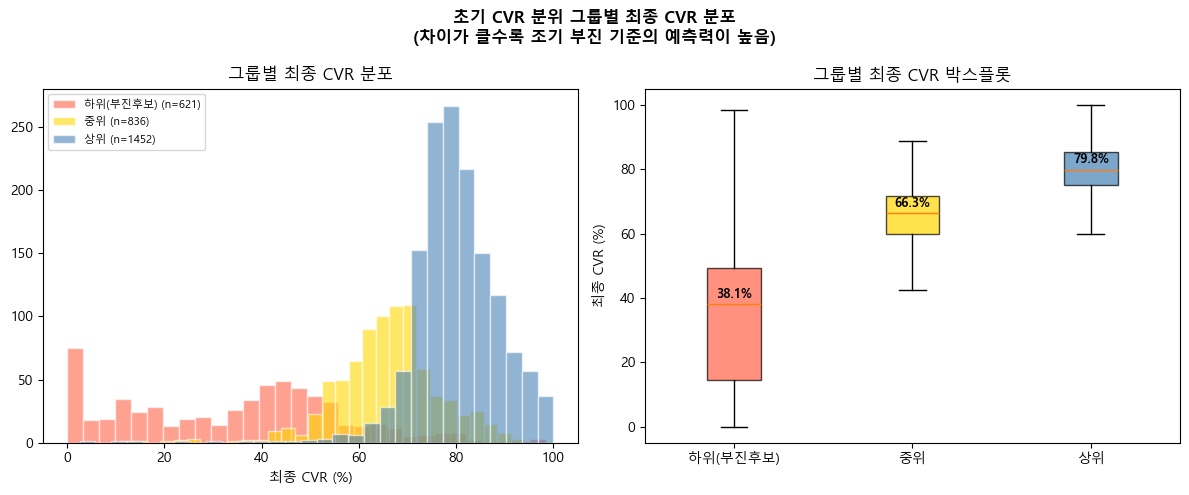

In [18]:
# ══════════════════════════════════════════════════════
# B-4. 초기 CVR 분위 → 최종 성과 차이 검증
# ══════════════════════════════════════════════════════
print("\n\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("추가 EDA B-4. 초기 CVR 분위별 최종 성과 비교")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

early3['type_p20'] = early3.groupby('analysis_ads_type_label')['early_cvr'].transform(
    lambda x: x.quantile(0.2)
)
early3['type_p50'] = early3.groupby('analysis_ads_type_label')['early_cvr'].transform(
    lambda x: x.quantile(0.5)
)

# 그룹 라벨 (유형별 상대 분위)
def assign_group(row):
    if row['early_cvr'] <= row['type_p20']:
        return '하위(부진후보)'
    elif row['early_cvr'] <= row['type_p50']:
        return '중위'
    else:
        return '상위'

early3['early_group'] = early3.apply(assign_group, axis=1)

group_stats = (early3.groupby('early_group')
               .agg(count           = ('ads_idx', 'count'),
                    final_cvr_mean  = ('cvr_pct', 'mean'),
                    final_cvr_med   = ('cvr_pct', 'median'),
                    smoothed_cvr_med= ('smoothed_cvr', 'median'))
               .reset_index())
print("\n[초기 CVR 그룹별 최종 성과 비교]")
print(group_stats.to_string(index=False))

# 하위 vs 상위 차이 출력
low  = early3[early3['early_group']=='하위(부진후보)']['cvr_pct'].median()
high = early3[early3['early_group']=='상위']['cvr_pct'].median()
print(f"\n▶ 하위 그룹 최종 CVR 중앙값: {low:.1f}%")
print(f"▶ 상위 그룹 최종 CVR 중앙값: {high:.1f}%")
print(f"▶ 차이: {high - low:.1f}%p  {'→ 기준 타당' if high-low > 10 else '→ 기준 재검토 필요'}")

groups_label = ['하위(부진후보)', '중위', '상위']
colors_d     = ['tomato', 'gold', 'steelblue']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('초기 CVR 분위 그룹별 최종 CVR 분포\n'
             '(차이가 클수록 조기 부진 기준의 예측력이 높음)',
             fontsize=12, fontweight='bold')

ax = axes[0]
for g, c in zip(groups_label, colors_d):
    data = early3[early3['early_group']==g]['cvr_pct'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=c, edgecolor='white', label=f'{g} (n={len(data)})')
ax.set_title('그룹별 최종 CVR 분포')
ax.set_xlabel('최종 CVR (%)')
ax.legend(fontsize=8)

ax = axes[1]
box_data = [early3[early3['early_group']==g]['cvr_pct'].dropna()
            for g in groups_label]
bp = ax.boxplot(box_data, labels=groups_label, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_d):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
# 중앙값 텍스트 표시
for j, g in enumerate(groups_label):
    med = early3[early3['early_group']==g]['cvr_pct'].median()
    ax.text(j+1, med+2, f'{med:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('그룹별 최종 CVR 박스플롯')
ax.set_ylabel('최종 CVR (%)')

plt.tight_layout()
plt.show()

In [19]:
# ── ad_attr_map 컬럼 확인 ───────────────────────────────────
attr = pd.read_parquet(r"C:/Users/hoo58/OneDrive/바탕 화면/tables/DATA/eda_ready_new/" + 'ad_attr_map.parquet')
print('ads_summary' in attr.columns)
print(attr.columns.tolist())


False
['ads_idx', 'ads_name', 'ads_type', 'ads_type_label', 'analysis_ads_type_label', 'analysis_ads_type_source', 'ads_category', 'category_name', 'ads_reward_price', 'reward_band', 'ads_order', 'ads_rejoin_type', 'ads_save_way', 'ads_day_cap', 'ads_sdate', 'ads_edate', 'ads_action_rule', 'ads_action_diff_flag']
